In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
import random

/home/caio-ragazzi/Documents/Study/langgraph/.venv/lib/python3.14/site-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [2]:
class AgentState(TypedDict):
    name: str
    number: list[int]
    counter: int

In [3]:
def greeting_node(state: AgentState) -> AgentState:
    """Greeting node which say hi to the person"""

    state['name'] = f"Hi there, {state['name']}"
    state['counter'] = 0
    return state

def random_node(state: AgentState) -> AgentState:
    """Generates a danom number from 0 to 10"""

    state['number'].append(random.randint(0, 10))
    state['counter'] += 1
    return state

def should_continue(state: AgentState) -> AgentState:
    """Function to decide what to do next"""

    if state['counter'] < 5:
        print("ENTERING LOOP", state['counter'])
        return "loop"
    else:
        return "exit"

In [ ]:
graph = StateGraph(AgentState)

graph.add_node("greeting", greeting_node)
graph.add_node("random", random_node)

graph.add_edge("greeting", "random")

graph.add_conditional_edges(
    "random",
    should_continue,
    {
        "loop": "random",
        "exit": END
    }
)

graph.set_entry_point("greeting")

app = graph.compile()

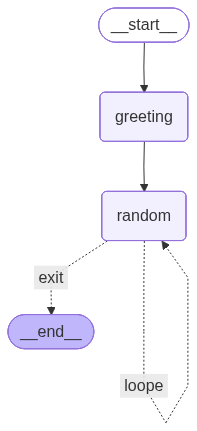

In [5]:
from IPython.display import Image

display(Image(app.get_graph().draw_mermaid_png()))